In [2]:
import torch
from torch import nn
from d2l import torch as d2l

In [3]:
#@save
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

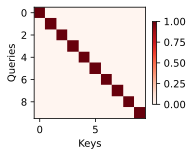

In [4]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

In [5]:
print("attention_weights", attention_weights)

attention_weights tensor([[[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]]]])


真实规律是 f(x)。x_train 是采样点，y_train = f(x_train) + 噪声 是对真实规律的带噪观测。y_truth = f(x_test) 是测试点上的无噪真值。目标是用 (x_train, y_train) 通过注意力池化（核回归）对 x_test 做预测，使预测值 y_hat 尽量接近 y_truth，从而验证模型学到了真实规律 f 而非过拟合噪声。

In [6]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本。 torch.rand返回(0,1]之间的随机数

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

In [7]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

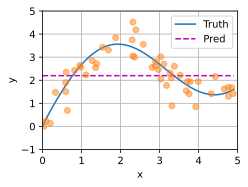

In [8]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

y_pred: tensor(-0.0002)
y_pred: tensor(0.0185)
y_pred: tensor(0.0292)
y_pred: tensor(0.1436)
y_pred: tensor(0.2742)
y_pred: tensor(0.3775)
y_pred: tensor(0.5379)
y_pred: tensor(0.5840)
y_pred: tensor(0.7263)
y_pred: tensor(0.8636)
y_pred: tensor(0.9940)
y_pred: tensor(1.0925)
y_pred: tensor(1.1970)
y_pred: tensor(1.2801)
y_pred: tensor(1.3657)
y_pred: tensor(1.4520)
y_pred: tensor(1.5174)
y_pred: tensor(1.5718)
y_pred: tensor(1.5938)
y_pred: tensor(1.6111)
y_pred: tensor(1.6364)
y_pred: tensor(1.6517)
y_pred: tensor(1.6714)
y_pred: tensor(1.6818)
y_pred: tensor(1.6859)
y_pred: tensor(1.6892)
y_pred: tensor(1.6927)
y_pred: tensor(1.6951)
y_pred: tensor(1.6976)
y_pred: tensor(1.6993)
y_pred: tensor(1.7011)
y_pred: tensor(1.7020)
y_pred: tensor(1.7029)
y_pred: tensor(1.7037)
y_pred: tensor(1.7040)
y_pred: tensor(1.7047)
y_pred: tensor(1.7050)
y_pred: tensor(1.7052)
y_pred: tensor(1.7053)
y_pred: tensor(1.7054)
y_pred: tensor(1.7056)
y_pred: tensor(1.7056)
y_pred: tensor(1.7057)
y_pred: te

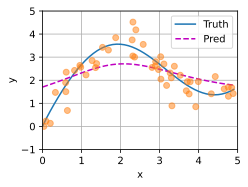

In [17]:
# y_pred=x_test和x_train之间的相似度作为权重乘上y_train的值。
# 注意力是x_test对剩下所有x_train的注意力

from sympy import print_glsl


def alpha(a_x_train, a_x_test):
    scores = -(a_x_train - a_x_test)**2/2
    return torch.exp(scores)


y_preds = []

for a_x_test in x_test:
    y_pred = 0
    scores = []

    for a_x_train in x_train:
        score = alpha(a_x_train, a_x_test)
        scores.append(score)
    score_sum = sum(scores)

    y_pred = 0
    for score, a_y_train in zip(scores, y_train):
        y_pred += score/score_sum*a_y_train
        print("y_pred:",y_pred)
    y_preds.append(y_pred)

plot_kernel_reg(y_preds)

